In [217]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib
import pickle
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# to do
import plot_helper_functions as hf

In [149]:
# settings
non_feature_cols = ['SMILES', 'MP', 'MP_label', 'Type']
figure_output_dir = "../Figures/final_figures/"
data_types = ['L', 'H', 'All']
color_scheme = {
    'L': '#4c72b0', 
    'H': '#dd8452',
    'All': '#55a868', 
    'Purple': '#8172b3',
    'Red': "#e74c3c",
    'Extra': '#4d4d4d'}

# Figure 1 (RFE feature selection)

In [87]:
figure_1_data_path = '../1_feature_engineering/feature_engineering_dict.pkl'
figure_1_data = pd.read_pickle(figure_1_data_path)
figure_1_data

{('LGB',
  'L'): {'summary':     iteration  n_features  rmse_mean  rmse_std  \
  0           0         329  34.011687  1.310579   
  1           1         324  34.034578  1.248050   
  2           2         319  33.960687  1.267883   
  3           3         314  33.886771  1.188937   
  4           4         309  33.963604  1.186171   
  ..        ...         ...        ...       ...   
  62         62          19  35.971765  0.987091   
  63         63          14  36.517163  0.862120   
  64         64           9  38.926584  0.982789   
  65         65           4  44.018719  1.150921   
  66         66           1  57.278277  0.709424   
  
                                      selected_features  \
  0   [MACCS_100, MACCS_101, MACCS_102, MACCS_103, M...   
  1   [MACCS_100, MACCS_101, MACCS_102, MACCS_103, M...   
  2   [MACCS_100, MACCS_101, MACCS_102, MACCS_103, M...   
  3   [MACCS_100, MACCS_101, MACCS_102, MACCS_103, M...   
  4   [MACCS_100, MACCS_101, MACCS_102, MACCS_103, 

In [125]:
def RFE_plot(RFE_results, tolerance, data_type, ann, model_type='LGB', ax=None, color_scheme=None):
    
    summary = RFE_results[(model_type, data_type)]['summary'].copy()
    
    # Sort by n_features to ensure line plot is correct
    summary = summary.sort_values(by='n_features')
    
    # Identify metric columns
    metric_col = [col for col in summary.columns if '_mean' in col][0]
    metric_std_col = metric_col.replace('_mean', '_std')
    metric_label = metric_col.split('_')[0].upper()
    
    # Identify best performance (Parsimonious: least features within tolerance of global best)
    if 'r2' in metric_col.lower():
        global_best = summary[metric_col].max()
        threshold = global_best - abs(global_best) * tolerance
        candidates = summary[summary[metric_col] >= threshold]
        best_idx = candidates['n_features'].idxmin()
        direction = 'max'
    else:
        global_best = summary[metric_col].min()
        threshold = global_best + abs(global_best) * tolerance
        candidates = summary[summary[metric_col] <= threshold]
        best_idx = candidates['n_features'].idxmin()
        direction = 'min'
        
    best_n = summary.loc[best_idx, 'n_features']
    best_score = summary.loc[best_idx, metric_col]
    
    # --- Plotting Style ---
    sns.set_theme(style="ticks", font_scale=1.1)
    
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define colors from color_scheme if provided
    if color_scheme is not None:
        line_color = color_scheme.get(data_type, "#2c3e50")
        fill_color = color_scheme.get(data_type, "#2c3e50")
        best_point_color = color_scheme.get('Extra', "#e74c3c")
    else:
        line_color = "#2c3e50"
        fill_color = "#3498db"
        best_point_color = "#e74c3c"
    
    # 1. Uncertainty Band (Std Dev)
    if metric_std_col in summary.columns:
        ax.fill_between(
            summary['n_features'], 
            summary[metric_col] - summary[metric_std_col],
            summary[metric_col] + summary[metric_std_col],
            color=fill_color, alpha=0.2, label='±1 Std. Dev.', zorder=1
        )
    
    # 2. Mean Score Line
    ax.plot(
        summary['n_features'], summary[metric_col], 
        color=line_color, linestyle='-', linewidth=2, 
        marker='o', markersize=5, markerfacecolor='white', markeredgewidth=1.5,
        label=f'Mean {metric_label}', zorder=2
    )
    
    # 3. Highlight Best Point
    ax.scatter(
        best_n, best_score, 
        color=best_point_color, s=150, zorder=3, 
        edgecolor='white', linewidth=2, label=f'Optimal ({best_n} features)'
    )
    
    # 4. Vertical Dropline for Best Point
    ax.vlines(x=best_n, ymin=ax.get_ylim()[0], ymax=best_score, 
              colors=best_point_color, linestyles=':', alpha=0.6, zorder=0)

    # 5. Annotation
    va_align = 'bottom' if direction == 'min' else 'top'
    text_offset = (0, 15) if direction == 'min' else (0, -15)
    
    ax.annotate(
        f'{metric_label} = {best_score:.2f}',
        xy=(best_n, best_score), xytext=text_offset,
        textcoords='offset points', ha='center', va=va_align,
        fontsize=14, color=best_point_color,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=best_point_color, alpha=1)
    )

    # Labels & Title
    ax.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Performance ({metric_label})', fontsize=12, fontweight='bold')
    if data_type == 'All':
        data_name = 'all data'
    if data_type == 'L':
        data_name = 'low mp data'
    if data_type == 'H':
        data_name = 'high mp data'
    ax.set_title(f'RFE: {data_name}', fontsize=18, pad=15)
    
    # Aesthetics
#    ax.set_ylim(20, 65)
    sns.despine(ax=ax, trim=True, offset=5)
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    ax.legend(loc='best', frameon=True, framealpha=1., facecolor='white', fontsize=14, title_fontsize=14)
    
    if standalone:
        plt.tight_layout()
        plt.show()

    ax.text(-0.05, 1.02, ann, transform=ax.transAxes, fontsize=14, va='top', ha='left')

    print(f"  [{data_type}] Optimal Feature Set: {best_n} features, Best {metric_label}: {best_score:.4f}")


  [L] Optimal Feature Set: 89 features, Best RMSE: 34.1129
  [H] Optimal Feature Set: 55 features, Best RMSE: 28.2607
  [All] Optimal Feature Set: 83 features, Best RMSE: 37.6197


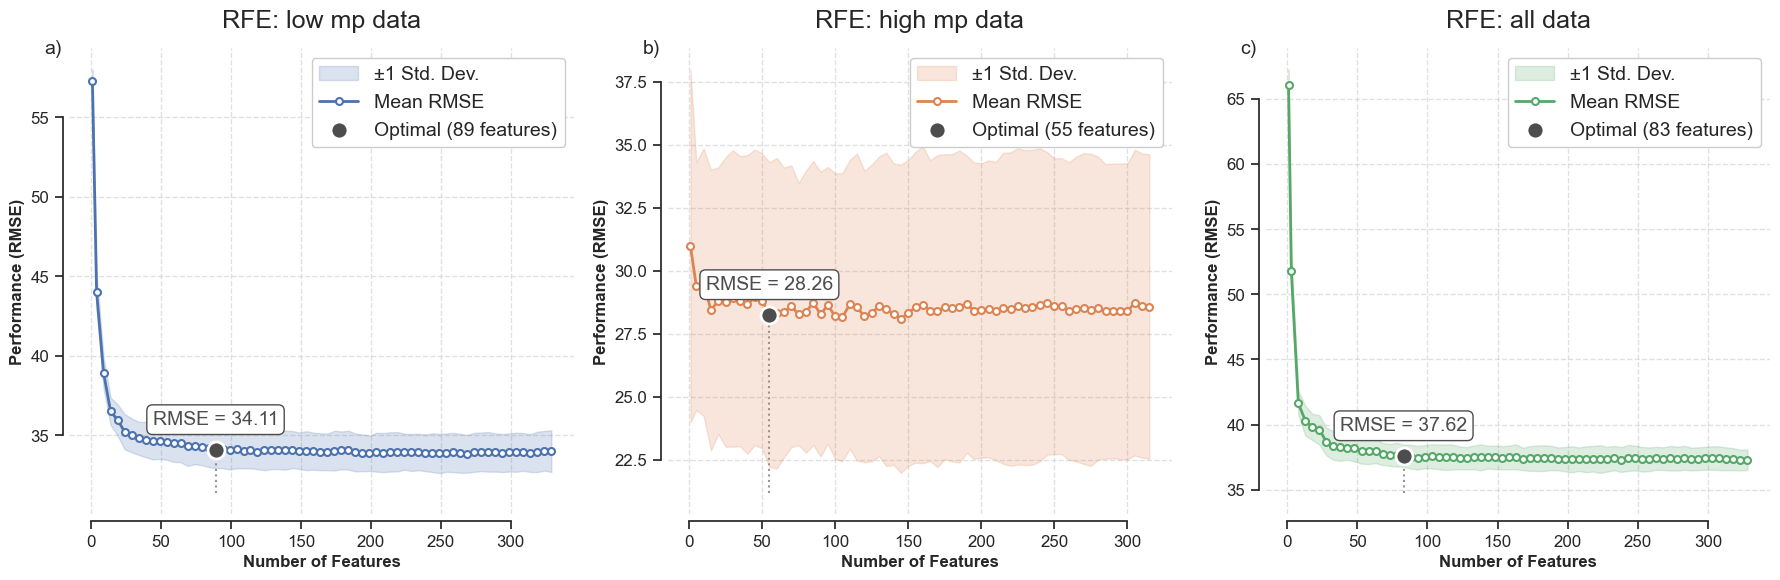

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, data_type in enumerate(data_types):
    RFE_plot(figure_1_data, ann = f'{chr(97+i)})', tolerance=0.01, data_type=data_type, ax=axes[i], color_scheme=color_scheme)
plt.tight_layout()
plt.show()
fig.savefig(figure_output_dir + 'figure_1_rfe.png', dpi=300)


# Figure 2 (model evaluation)

In [96]:
best_model_path = '../2_model_development/best_model_LGB_'
hp_tuning_results_path = '../2_model_development/model_development_results_LGB_'
figure_2_results_path = '../3_model_evaluation/model_evaluation_results_LGB_'

In [91]:
best_models = {}
for data_type in data_types:
    best_models[data_type] = joblib.load(best_model_path + data_type + '.joblib')

In [95]:
hp_tuning_results = {}
for data_type in data_types:
    hp_tuning_results[data_type] = pickle.load(open(hp_tuning_results_path + data_type + '.pkl', 'rb'))


In [97]:
figure_2_results = {}
for data_type in data_types:
    figure_2_results[data_type] = pd.read_csv(figure_2_results_path + data_type + '.csv')

In [102]:
figure_2_results['L']

,SMILES,MP,Type,MP_label,RDKit_TPSA,RDKit_FpDensityMorgan3,RDKit_BCUT2D_MRHI,RDKit_SMR_VSA10,RDKit_VSA_EState4,RDKit_NumRotatableBonds,...,RDKit_fr_imidazole,RDKit_PEOE_VSA2,RDKit_Chi2n,RDKit_PEOE_VSA1,RDKit_PEOE_VSA11,RDKit_fr_Ar_NH,RDKit_NumHeteroatoms,RDKit_EState_VSA5,RDKit_PEOE_VSA12,MP_pred
0,C/C(=C\C(=N/Nc1ccc(cc1[N+](=O)[O-])[N+](=O)[O-...,115.0,Test,L,1.654480,0.273579,-0.382929,0.802312,0.954722,1.262156,...,-0.133569,3.394771,0.667614,-0.997500,-0.526686,-0.20324,1.303088,0.008623,-0.430461,206.316344
1,COC(=O)C(=C(SCc1ccccc1)SCc1ccccc1)C#N,104.0,Test,L,-0.048016,-0.835231,1.143182,0.846509,0.197132,1.262156,...,-0.133569,-0.782622,0.304196,-0.378006,0.481551,-0.20324,0.215693,1.042874,-0.430461,80.117069
2,CC(=O)c1ccc(c(c1)F)O,128.0,Test,L,-0.407457,0.783228,-0.385814,-0.782647,-0.532178,-0.561777,...,-0.133569,-0.001912,-0.744034,-0.329661,2.612120,-0.20324,-0.509237,0.056553,-0.430461,119.875716
3,NC(=O)C1=C(CCCC1)CCc1ccccc1,113.0,Test,L,-0.244739,0.465599,-0.393950,-0.774131,2.498959,0.350190,...,-0.133569,-0.001912,0.233292,-0.247642,-0.526686,-0.20324,-0.871702,0.311877,1.141924,124.833423
4,OCCOc1ccccc1,12.0,Test,L,-0.627787,0.521953,-0.879120,-1.180027,-0.624490,0.046201,...,-0.133569,-0.782622,-0.880423,0.289833,-0.526686,-0.20324,-0.871702,-0.669632,-0.430461,27.368673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,158.5,Test,L,0.754332,1.029135,-0.730187,-0.789234,-0.438388,0.958167,...,-0.133569,0.864325,-0.004857,1.006495,-0.526686,-0.20324,0.578158,0.347751,-0.430461,130.348581
5162,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,120.0,Test,L,-1.455709,-2.139191,0.220226,-0.070479,2.497540,-0.865765,...,-0.133569,-0.782622,1.017151,-0.997500,-0.526686,-0.20324,-0.871702,-0.669632,-0.430461,109.510583
5163,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],34.0,Test,L,-0.243334,0.248235,1.741828,0.305349,-1.392120,-0.561777,...,-0.133569,0.864325,-0.665594,-0.997500,-0.526686,-0.20324,0.940623,-0.330504,-0.430461,41.657095
5164,OC(=O)C(C(=O)O)Cc1ccccc1,121.0,Test,L,0.640795,-0.436059,-0.392435,-0.359698,-0.376220,0.350190,...,-0.133569,0.778798,-0.462402,0.338179,0.543929,-0.20324,-0.146772,-0.669632,-0.430461,149.632992


In [ ]:
def compute_metrics(df):
    """Return dict of (rmse, mae) for L, H, and All subsets."""
    results = {}
    for label in ['L', 'H']:
        subset = df[df['MP_label'] == label]
        if len(subset) > 0:
            rmse = np.sqrt(mean_squared_error(subset['MP'], subset['MP_pred']))
            mae  = mean_absolute_error(subset['MP'], subset['MP_pred'])
        else:
            rmse, mae = np.nan, np.nan
        results[label] = (rmse, mae)
    rmse_all = np.sqrt(mean_squared_error(df['MP'], df['MP_pred']))
    mae_all  = mean_absolute_error(df['MP'], df['MP_pred'])
    results['All'] = (rmse_all, mae_all)
    return results


def model_eval_plot(figure_2_results, metric, ax, color_scheme=None, ann=None, show_legend=False):

    metric_idx = {'RMSE': 0, 'MAE': 1}
    metric_labels = {'RMSE': 'RMSE (°C)', 'MAE': 'MAE (°C)'}

    model_keys    = ['L', 'H', 'All']
    subset_keys   = ['L', 'H', 'All']
    subset_labels = {'L': 'Low MP data', 'H': 'High MP data', 'All': 'All data '}
    model_labels  = {'L': 'Low MP\nmodel', 'H': 'High MP\nmodel', 'All': 'All data\nmodel'}

    if color_scheme is None:
        color_scheme = {'L': '#4c72b0', 'H': '#dd8452', 'All': '#55a868'}

    metrics_data = {mk: compute_metrics(figure_2_results[mk]) for mk in model_keys}

    n_groups    = len(model_keys)
    n_bars      = len(subset_keys)
    bar_width   = 0.15
    group_gap   = 0.45
    group_width = n_bars * bar_width + group_gap
    x_centers   = np.arange(n_groups) * group_width

    m_idx = metric_idx[metric]

    for b_idx, sk in enumerate(subset_keys):
        offsets = x_centers + (b_idx - (n_bars - 1) / 2) * bar_width
        values  = [metrics_data[mk][sk][m_idx] for mk in model_keys]
        color   = color_scheme.get(sk, '#333333')

        bars = ax.bar(
            offsets, values,
            width=bar_width * 0.9,
            color=color, alpha=0.85,
            label=subset_labels[sk],
            edgecolor='white', linewidth=0.8
        )
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.15,
                    f'{round(val)}',
                    ha='center', va='bottom', fontsize=12, color=color
                )

    ax.set_ylabel(metric_labels[metric], fontsize=12, fontweight='bold')
    ax.set_xticks(x_centers)
    ax.set_xticklabels([model_labels[mk] for mk in model_keys], fontsize=11)

    ax.set_ylim(0, 180)
    sns.despine(ax=ax, trim=False, offset=5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    if show_legend:
        ax.legend(title='Evaluated on', frameon=True, framealpha=0.95,
                  facecolor='white', fontsize=10, title_fontsize=10)

    if ann is not None:
        ax.text(-0.08, 1.09, ann, transform=ax.transAxes, fontsize=14, va='top', ha='left')


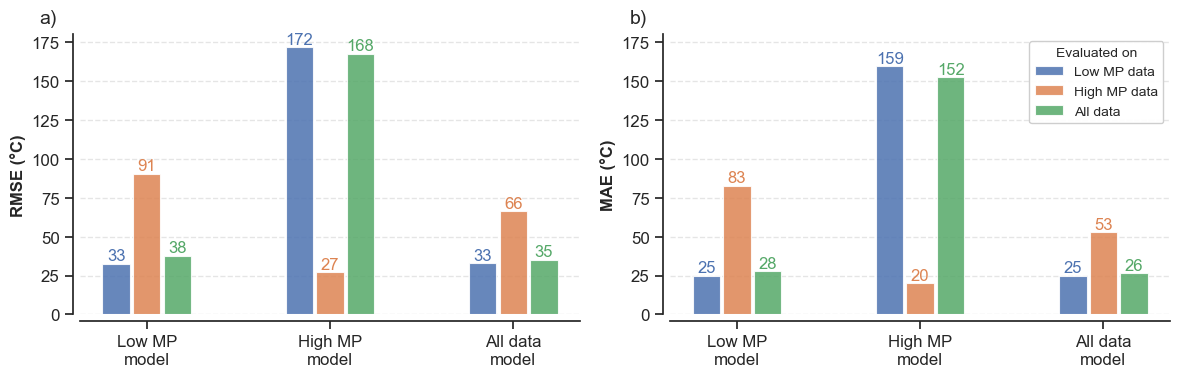

In [122]:
metrics = ['RMSE', 'MAE']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# sns.set_theme(style="ticks", font_scale=1.1)
for i, metric in enumerate(metrics):
    model_eval_plot(figure_2_results, metric, ax=axes[i], color_scheme=color_scheme,
                    ann=f'{chr(97+i)})', show_legend=(i == len(metrics) - 1))
plt.tight_layout()
plt.show()
fig.savefig(figure_output_dir + 'figure_2_model_eval.png', dpi=300)

## Figure S LGB HP tuning

# Figure 3 (L/H MP data analysis)

In [136]:
figure_3_all_data_path = '../0_data/processed_data/data_with_all_features_scaled.parquet'
figure_3_L_data_path = '../0_data/processed_data/data_with_selected_features_LGB_L.parquet'
figure_3_H_data_path = '../0_data/processed_data/data_with_selected_features_LGB_H.parquet'

In [144]:
H_cols = pd.read_parquet(figure_3_H_data_path).columns.tolist()
L_cols = pd.read_parquet(figure_3_L_data_path).columns.tolist()

# combine the two column lists and remove duplicates
combined_cols = list(dict.fromkeys(H_cols + L_cols))

print(f"H model features: {len(H_cols)}")
print(f"L model features: {len(L_cols)}")
print(f"Combined features: {len(combined_cols)}")

figure_3_data_ = pd.read_parquet(figure_3_all_data_path)[combined_cols]
figure_3_data = figure_3_data_[figure_3_data_['Type'] == 'Train']

print(f"Figure 3 data shape: {figure_3_data.shape}")

H model features: 59
L model features: 93
Combined features: 100
Figure 3 data shape: (12054, 100)


In [ ]:
_PROP_FUNCS = {
    'MP':   None,  # already in df
    'MW':   Descriptors.MolWt,
    'LogP': Descriptors.MolLogP,
    'HBD':  Descriptors.NumHDonors,
    'HBA':  Descriptors.NumHAcceptors,
    'TPSA': Descriptors.TPSA,
    'RingCount': Descriptors.RingCount
}

_LABEL_MAP = {'L': 'Low MP', 'H': 'High MP', 'All': 'All'}

def _ensure_properties(df, smiles_col, props):
    """Compute any missing RDKit properties from SMILES (returns copy if needed)."""
    missing = [p for p in props if p != 'MP' and p not in df.columns]
    if not missing:
        return df
    df = df.copy()
    mols = [Chem.MolFromSmiles(s) for s in df[smiles_col]]
    for prop in missing:
        df[prop] = [_PROP_FUNCS[prop](m) if m else float('nan') for m in mols]
    return df


def property_plot(df, prop, prop_label, ax, x_col, color_scheme,
                  show_outliers, smiles_col='SMILES', ann=None, show_legend=False):
    """
    Boxen plot of a single molecular property grouped by x_col.

    Parameters
    ----------
    prop          : column name of the property to plot
    prop_label    : y-axis label
    x_col         : column used for grouping (e.g. 'MP_label')
    color_scheme  : dict mapping group keys to hex colours
    show_outliers : bool — whether to show outlier points on the boxen plot
    show_legend   : only the last subplot needs the legend
    """
    df = _ensure_properties(df, smiles_col, [prop])

    present     = df[x_col].unique()
    group_order = [k for k in color_scheme if k in present]
    palette     = {k: color_scheme[k] for k in group_order}

    outlier_kws = {} if show_outliers else {'showfliers': False}
    sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
                  palette=palette, ax=ax, **outlier_kws)

    ax.set_ylabel(prop_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
    sns.despine(ax=ax, trim=False, offset=5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    if show_legend:
        means   = df.groupby(x_col)[prop].mean()
        handles = []
        for grp in group_order:
            if grp not in means.index:
                continue
            display = _LABEL_MAP.get(grp, grp)

            if prop == 'RingCount':
                patch = mpatches.Patch(color=color_scheme[grp],
                                    label=f'{display}  (mean: {round(means[grp],1)})')
            else:
                patch = mpatches.Patch(color=color_scheme[grp],
                        label=f'{display}  (mean: {round(means[grp])})')
            handles.append(patch)
        ax.legend(handles=handles, frameon=True, framealpha=0.95,
                  facecolor='white', fontsize=9, title_fontsize=9)

    if ann is not None:
        ax.text(-0.12, 1.16, ann, transform=ax.transAxes, fontsize=14, va='top', ha='left')


In [ ]:
def pca_plot(df, hue_col, subplotspec, fig, color_scheme,
             non_feature_cols=non_feature_cols,
             show_marginals=True, xlim=None, ylim=None, ann=None, show_legend=False):
    """
    PCA joint KDE plot, optionally with PC1 (top) and PC2 (right) marginal KDEs.

    Parameters
    ----------
    subplotspec   : GridSpec cell (e.g. gs[0:2, 0:2]) for the PCA area
    fig           : the parent Figure
    hue_col       : column in df for colouring (e.g. 'MP_label')
    color_scheme  : dict mapping group keys to hex colours
    show_marginals: bool — toggle top/right marginal KDE panels
    """
    features_df = df.drop(columns=non_feature_cols)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features_df)

    pca_model = PCA(n_components=2)
    pcs = pca_model.fit_transform(X_scaled)
    ev  = pca_model.explained_variance_ratio_

    df_plot = pd.DataFrame({'PC1': pcs[:, 0], 'PC2': pcs[:, 1]})
    df_plot[hue_col] = df[hue_col].values

    present     = df_plot[hue_col].unique()
    group_order = [k for k in color_scheme if k in present]

    cut    = 3
    thresh = 0.02
    levels = 12

    if show_marginals:
        # Nested 2×2: top-left=top marginal, bottom-left=joint, bottom-right=right marginal
        inner = GridSpecFromSubplotSpec(
            2, 2, subplot_spec=subplotspec,
            width_ratios=[5, 1], height_ratios=[1, 5],
            hspace=0.05, wspace=0.05
        )
        ax_top   = fig.add_subplot(inner[0, 0])
        ax_joint = fig.add_subplot(inner[1, 0])
        ax_right = fig.add_subplot(inner[1, 1])
        fig.add_subplot(inner[0, 1]).set_visible(False)  # empty corner
    else:
        ax_joint = fig.add_subplot(subplotspec)
        ax_top   = None
        ax_right = None

    for label in group_order:
        subset = df_plot[df_plot[hue_col] == label]
        if len(subset) < 2:
            continue
        color = color_scheme[label]

        # Joint 2D KDE
        sns.kdeplot(data=subset, x='PC1', y='PC2', ax=ax_joint,
                    color=color, fill=True, alpha=0.5,
                    levels=levels, thresh=thresh, cut=cut, common_norm=False)
        sns.kdeplot(data=subset, x='PC1', y='PC2', ax=ax_joint,
                    color=color, fill=False, linewidths=1.5,
                    levels=levels, thresh=thresh, cut=cut, common_norm=False)

        if show_marginals:
            sns.kdeplot(data=subset, x='PC1', ax=ax_top,
                        color=color, fill=True, alpha=0.4, cut=cut, common_norm=False)
            sns.kdeplot(data=subset, y='PC2', ax=ax_right,
                        color=color, fill=True, alpha=0.4, cut=cut, common_norm=False)

    ax_joint.set_xlabel(f'PC1 ({ev[0]:.1%})', fontsize=12, fontweight='bold')
    ax_joint.set_ylabel(f'PC2 ({ev[1]:.1%})', fontsize=12, fontweight='bold')
    if xlim is not None:
        ax_joint.set_xlim(xlim)
    if ylim is not None:
        ax_joint.set_ylim(ylim)
    sns.despine(ax=ax_joint, trim=False, offset=5)
    ax_joint.grid(True, linestyle='--', alpha=0.4)

    if show_marginals:
        ax_top.set_xlim(ax_joint.get_xlim())
        ax_top.set_xlabel('')
        ax_top.set_ylabel('')
        ax_right.set_ylim(ax_joint.get_ylim())  # synced to joint (respects ylim)
        sns.despine(ax=ax_top, left=True, bottom=False, offset=3)
        ax_top.set_yticks([])

        ax_right.set_ylim(ax_joint.get_ylim())
        ax_right.set_ylabel('')
        ax_right.set_xlabel('')
        plt.setp(ax_right.get_yticklabels(), visible=False)
        sns.despine(ax=ax_right, left=False, bottom=True, offset=3)
        ax_right.set_xticks([])

    if show_legend:
        _label_map = {'L': 'Low MP', 'H': 'High MP', 'All': 'All'}
        handles = [mpatches.Patch(color=color_scheme[k], label=_label_map.get(k, k))
                   for k in group_order if k in color_scheme]
        ax_joint.legend(handles=handles, frameon=True, framealpha=0.95,
                        facecolor='white', fontsize=9, title_fontsize=9)

    if ann is not None:
        ann_ax = ax_top if show_marginals else ax_joint
        offset = 1.15 if show_marginals else 1.08
        ann_ax.text(-0.05, offset, ann, transform=ann_ax.transAxes, fontsize=14, va='top', ha='left')

/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_52206/3328609028.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_52206/3328609028.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_52206/3328609028.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_

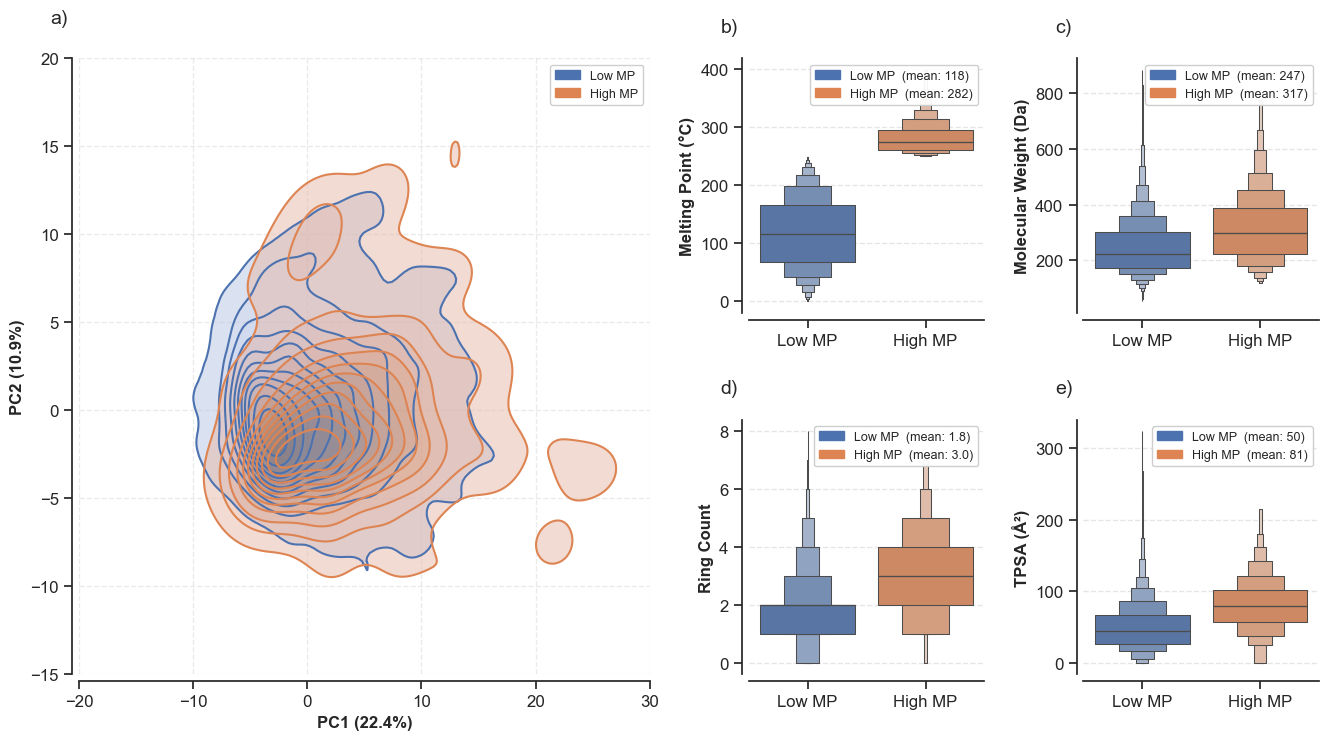

In [ ]:
properties = [
    ('MP',   'Melting Point (°C)'),
    ('MW',   'Molecular Weight (Da)'),
    ('RingCount', 'Ring Count'),
    ('TPSA', 'TPSA (Å²)'),
]

sns.set_theme(style="ticks", font_scale=1.1)
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.42, hspace=0.42)

# PCA occupies left 2×2 block — pass SubplotSpec for nested marginals
pca_plot(figure_3_data, 'MP_label',
         gs[0:2, 0:2], fig, color_scheme=color_scheme,
         xlim=[-20, 30], ylim=[-15, 20], ann='a)', show_legend=True, show_marginals=False)

# 4 properties fill the right 2×2 block
prop_positions = [(0, 2), (0, 3), (1, 2), (1, 3)]
for i, ((row, col), (prop, label)) in enumerate(zip(prop_positions, properties)):
    ax = fig.add_subplot(gs[row, col])
    property_plot(figure_3_data, prop, label, ax=ax, x_col='MP_label',
                  color_scheme=color_scheme, smiles_col='SMILES', show_outliers=False,
                  ann=f'{chr(98+i)})', show_legend=True)

plt.tight_layout()
plt.show()
fig.savefig(figure_output_dir + 'figure_3_pca_properties.png', dpi=300)


# Figure 4 (feature importance analysis)

In [212]:
figure_4_model_path_prefix  = '../2_model_development/'
figure_4_data_prefix = '../3_model_evaluation/model_evaluation_results_'

In [213]:
model_H = joblib.load(f"{figure_4_model_path_prefix}best_model_LGB_H.joblib")
model_L = joblib.load(f"{figure_4_model_path_prefix}best_model_LGB_L.joblib")

In [214]:
data_H  = pd.read_csv(figure_4_data_prefix + "LGB_H.csv")
data_H = data_H[data_H['MP_label'] == 'H']

data_L  = pd.read_csv(figure_4_data_prefix + "LGB_L.csv")
data_L = data_L[data_L['MP_label'] == 'L']

In [236]:
def shap_analysis(model_L, model_H, data_L, data_H, n=10):

    def _compute(model, data):
        X        = data.drop(columns=non_feature_cols, errors='ignore')
        # Align columns to match the model's expected feature order
        expected_features = model.feature_name_
        X = X[expected_features]
        exp      = shap.TreeExplainer(model)
        sv       = exp.shap_values(X)
        mean_abs = np.abs(sv).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:n]
        feats    = X.columns[top_idx].tolist()
        vals     = mean_abs[top_idx]
        return X, sv, feats, vals, exp

    XL, svL, featsL, valsL, expL = _compute(model_L, data_L)
    XH, svH, featsH, valsH, expH = _compute(model_H, data_H)

    setL, setH = set(featsL), set(featsH)

    # ── Colours ──────────────────────────────────────────────────────
    CL, CH           = color_scheme['L'], color_scheme['H']
    CL_edge, CH_edge = color_scheme['L'], color_scheme['H']
    C_BOTH           = color_scheme['Extra']

    def _label_color(feat, own_color):
        if feat in setL and feat in setH:
            return C_BOTH
        return own_color

    rcParams.update({
        'font.family'      : 'sans-serif',
        'font.sans-serif'  : ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size'        : 10,
        'axes.linewidth'   : 0.8,
        'xtick.major.width': 0.6,
        'ytick.major.width': 0.6,
    })

    # Shared x limit
    xmax = max(valsL.max(), valsH.max()) * 1.12

    panel_h = max(4, n * 0.8)
    fig = plt.figure(figsize=(16, panel_h), facecolor='white', dpi=150)
    gs  = fig.add_gridspec(1, 2, wspace=0.08, top=0.88, bottom=0.12,
                           left=0.05, right=0.95)
    axL = fig.add_subplot(gs[0, 0])   # left  – model_L / data_L
    axH = fig.add_subplot(gs[0, 1])   # right – model_H / data_H

    bh = 0.62
    # y positions: most important (index 0) at the top → highest y value
    yL = np.arange(len(featsL) - 1, -1, -1)
    yH = np.arange(len(featsH) - 1, -1, -1)
    gap = xmax * 0.025   # small offset from the bar tip

    # ── Left panel – model_L, bars LEFT, labels at LEFT tip ────────────
    axL.barh(yL, valsL, height=bh, color=CL, edgecolor=CL_edge,
             linewidth=0.5, zorder=3)
    axL.set_xlim(0, xmax)
    axL.invert_xaxis()                 # bars extend leftward; x=0 is on the right
    axL.set_ylim(-0.6, len(featsL) - 0.4)
    axL.set_yticks([])                 # no y-tick labels; we annotate manually
    axL.tick_params(axis='x', labelsize=9, length=3)
    axL.set_xlabel('Low MP Model Mean SHAP value', fontsize=11, labelpad=5)
    axL.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.55, zorder=0)
    axL.spines['top'].set_visible(False)
    axL.spines['left'].set_visible(False)
    axL.spines['right'].set_linewidth(0.7)
    axL.spines['bottom'].set_linewidth(0.7)
    axL.set_title(f'Low MP Model', fontsize=12, 
                  #fontweight='bold',
                  color=CL, pad=9)

    # Feature names at the left tip
    for yi, (feat, val) in zip(yL, zip(featsL, valsL)):
        axL.text(val + gap, yi, feat,
                 ha='right', va='center', fontsize=9, 
                 color=_label_color(feat, CL), zorder=6)

    # ── Right panel – model_H, bars RIGHT, labels at RIGHT tip ──────────
    axH.barh(yH, valsH, height=bh, color=CH, edgecolor=CH_edge,
             linewidth=0.5, zorder=3)
    axH.set_xlim(0, xmax)
    axH.set_ylim(-0.6, len(featsH) - 0.4)
    axH.set_yticks([])
    axH.tick_params(axis='x', labelsize=9, length=3)
    axH.set_xlabel('Hig MP Model Mean SHAP value', fontsize=11, labelpad=5)
    axH.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.55, zorder=0)
    axH.spines['top'].set_visible(False)
    axH.spines['right'].set_visible(False)
    axH.spines['left'].set_linewidth(0.7)
    axH.spines['bottom'].set_linewidth(0.7)
    axH.set_title(f'High MP Model', fontsize=12,
                  color=CH, pad=9)

    # Feature names at the right tip
    for yi, (feat, val) in zip(yH, zip(featsH, valsH)):
        axH.text(val + gap, yi, feat,
                 ha='left', va='center', fontsize=9,
                 color=_label_color(feat, CH), zorder=6)


    plt.show()
    fig.savefig(figure_output_dir + 'figure_4_shap_comparison.png', dpi=300)

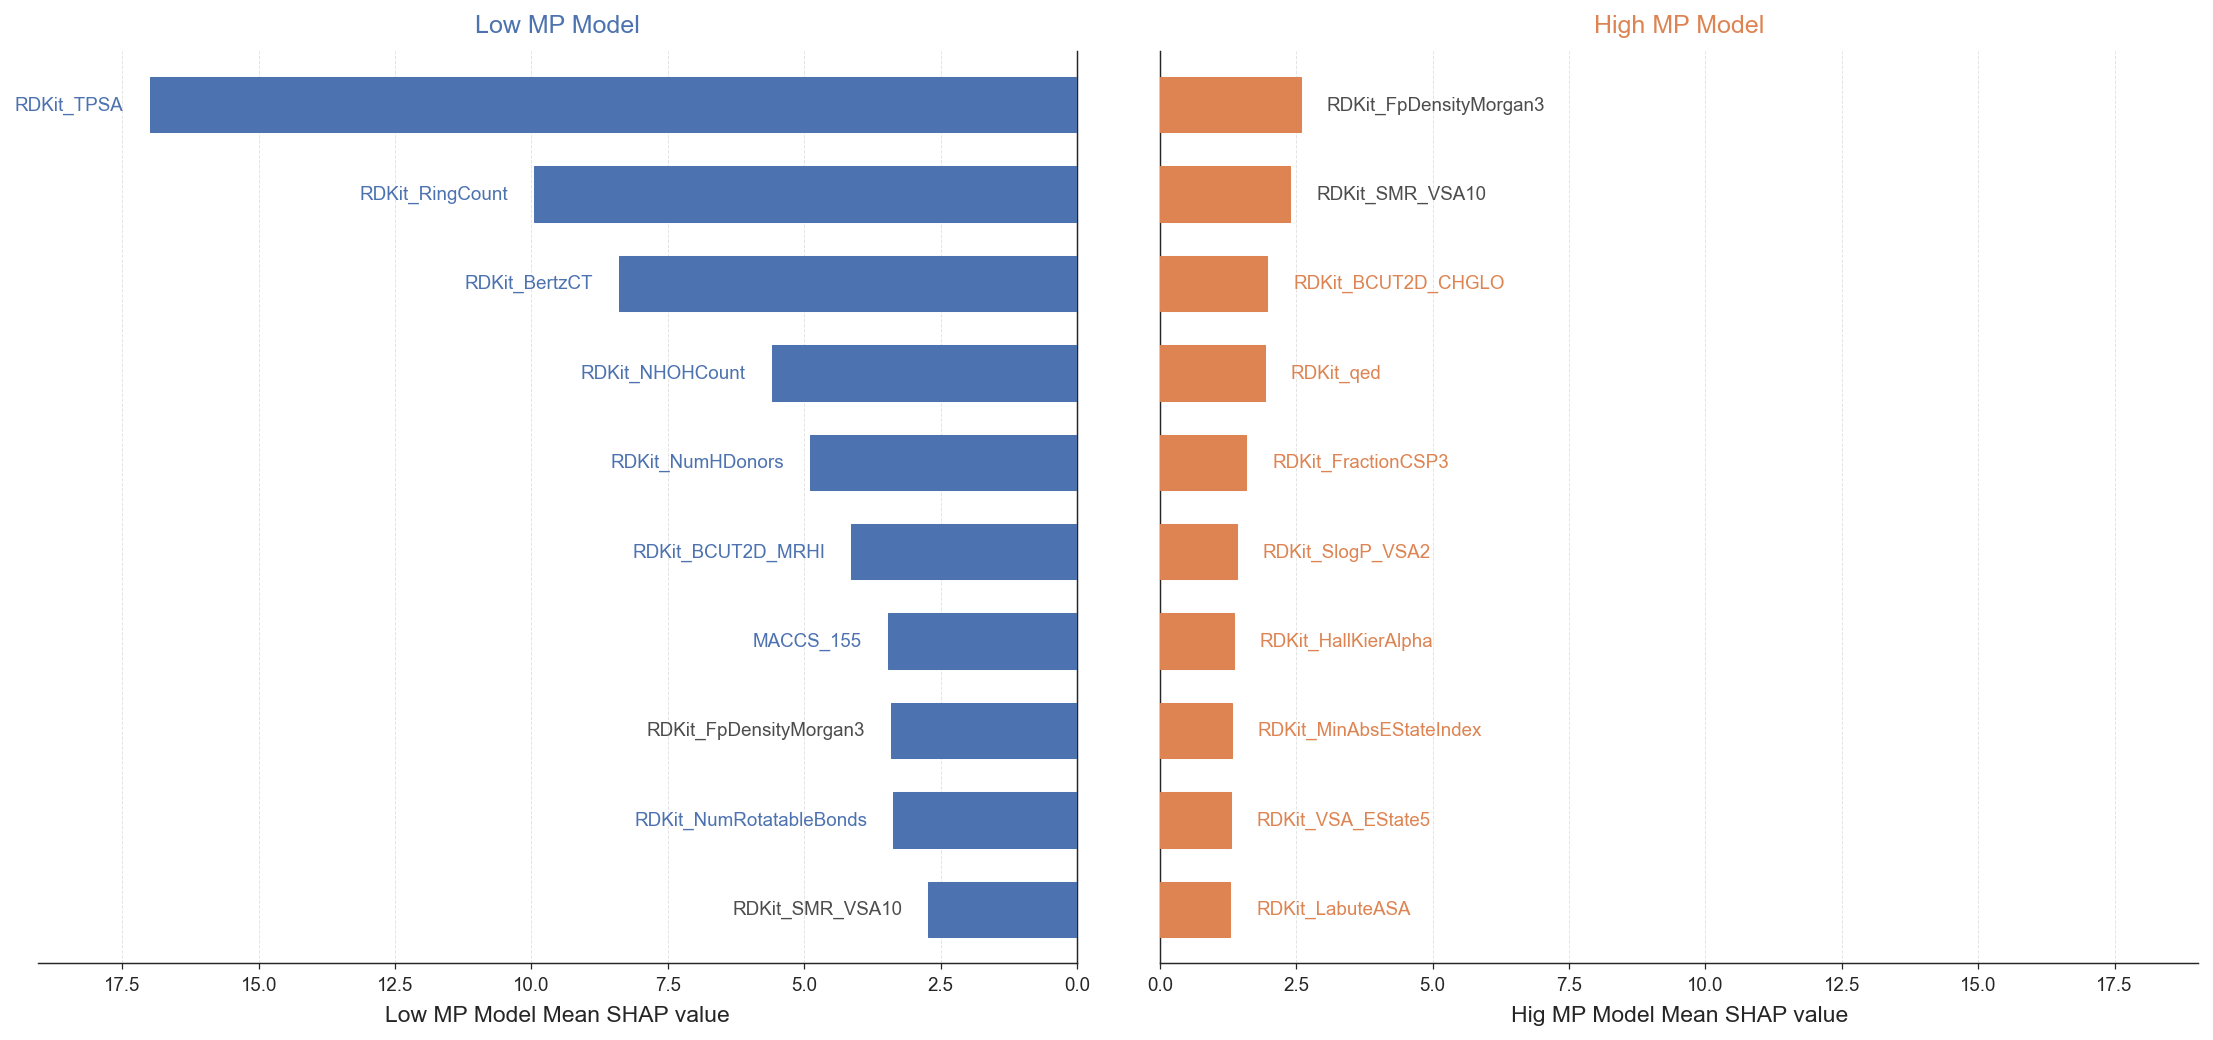

In [237]:
shap_analysis(model_L, model_H, data_L, data_H, n=10)

# Figure 5 (model confidence)

In [238]:
figure_5_data_path = '../5_model_confidence/model_confidence_results_LGB_All.csv'

In [241]:
figure_5_data = pd.read_csv(figure_5_data_path)
figure_5_data

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,MP_pred,AE,lower,upper,uncertainty
0,C/C(=C\C(=N/Nc1ccc(cc1[N+](=O)[O-])[N+](=O)[O-...,115.0,Test,L,0.273579,1.654480,1.262156,0.802312,0.225087,-1.105193,...,-0.488331,-0.586923,-0.562084,-0.133569,1.401025,202.769161,87.769161,162.833457,224.972141,62.138684
1,COC(=O)C(=C(SCc1ccccc1)SCc1ccccc1)C#N,104.0,Test,L,-0.835231,-0.048016,1.262156,0.846509,0.612333,-0.617962,...,-0.488331,0.374209,-0.562084,-0.133569,0.908283,75.548708,28.451292,54.184674,118.722408,64.537735
2,CC(=O)c1ccc(c(c1)F)O,128.0,Test,L,0.783228,-0.407457,-0.561777,-0.782647,-0.440110,-0.171672,...,-0.488331,0.323579,-0.562084,-0.133569,-0.746893,106.923252,21.076748,62.565644,136.640794,74.075151
3,NC(=O)C1=C(CCCC1)CCc1ccccc1,113.0,Test,L,0.465599,-0.244739,0.350190,-0.774131,0.168145,-0.578826,...,-0.488331,-0.586923,-0.562084,-0.133569,-0.056709,117.835232,4.835232,95.067569,151.462658,56.395089
4,OCCOc1ccccc1,12.0,Test,L,0.521953,-0.627787,0.046201,-1.180027,-0.902406,0.016888,...,-0.488331,0.323579,-0.562084,-0.133569,-0.972721,23.300981,11.300981,16.027778,79.939339,63.911561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,158.5,Test,L,1.029135,0.754332,0.958167,-0.789234,-0.107671,-1.088784,...,-0.488331,0.323579,1.779092,-0.133569,0.084641,126.424089,32.075911,99.403890,160.957581,61.553691
5162,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,120.0,Test,L,-2.139191,-1.455709,-0.865765,-0.070479,-0.999456,2.659783,...,-0.488331,3.044038,-0.562084,-0.133569,0.268670,98.678745,21.321255,64.340076,119.138970,54.798894
5163,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],34.0,Test,L,0.248235,-0.243334,-0.561777,0.305349,0.655692,-1.094674,...,-0.488331,-0.586923,-0.562084,-0.133569,-0.275050,39.153987,5.153987,36.742040,72.061799,35.319759
5164,OC(=O)C(C(=O)O)Cc1ccccc1,121.0,Test,L,-0.436059,0.640795,0.350190,-0.359698,-0.795887,-0.653368,...,2.047792,-0.586923,1.779092,-0.133569,-0.346521,151.869502,30.869502,127.668893,184.380791,56.711897
